In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.spatial import ConvexHull

In [3]:
#load the dataset
df = pd.read_csv("../../processed_scaled.csv")

#checking the dataset
print(df.shape)
df.head()

(7043, 15)


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,Contract,MonthlyCharges,Churn,internet_fiber,TotalCharges,TenureGroup_13-24m,TenureGroup_25-48m,TenureGroup_49-72m,HighValueCustomer
0,0,0,0,-1.277445,0,0,0,-1.321350,1,False,-0.995538,False,False,False,0
1,1,0,0,0.351370,1,0,1,-1.321350,0,False,-0.553953,False,True,False,0
2,0,0,1,0.799294,1,0,0,-1.520755,0,False,-0.570291,False,False,True,0
3,0,0,0,-1.277445,1,0,1,0.373593,1,False,-0.973018,False,False,False,0
4,1,0,0,1.410099,1,0,0,-0.457261,0,True,0.502321,False,False,True,0


In [4]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 302


In [6]:
# Remove duplicate rows
df = df.drop_duplicates()

# Verify
print("Dataset Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape: (6741, 15)
Duplicate Rows: 0


In [10]:
 #Remove the target variable
X = df.drop("Churn", axis=1)

print(X.shape)

(6741, 14)


In [11]:
print(df.dtypes)

gender                  int64
SeniorCitizen           int64
Dependents              int64
tenure                float64
PhoneService            int64
MultipleLines           int64
Contract                int64
MonthlyCharges        float64
Churn                   int64
internet_fiber           bool
TotalCharges          float64
TenureGroup_13-24m       bool
TenureGroup_25-48m       bool
TenureGroup_49-72m       bool
HighValueCustomer       int64
dtype: object


In [12]:
#Prepare Features for PCA and Clustering
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
#Train The model
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X)

df["Cluster"] = clusters

In [18]:
#Reduce the Data to 2 Dimensions (PCA)
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

In [19]:
cluster_names = {
    0: "Medium-risk customers",
    1: "New low-value customers",
    2: "Stable long-term customers",
    3: "High-risk mid-term customers"
}

df["Customer_Type"] = df["Cluster"].map(cluster_names)

/Users/sitabasnet/anaconda3/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


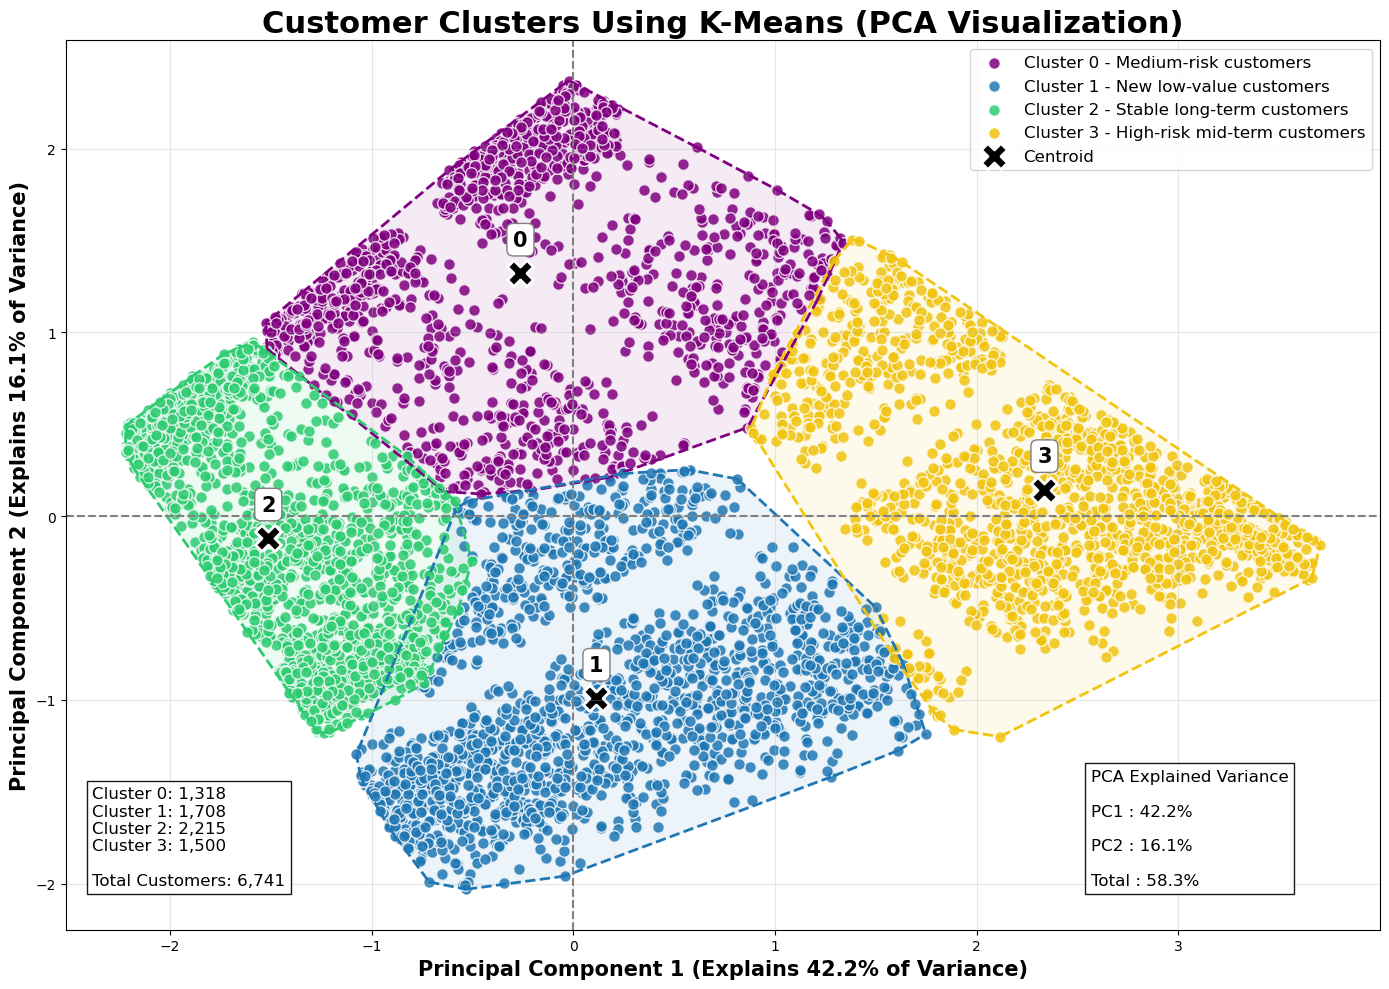

In [20]:

# Centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)


# Colors

colors = ['purple', '#1f77b4', '#2ecc71', '#f1c40f']

plt.figure(figsize=(14,10))

ax = plt.gca()


# Plot each cluster

for i, color in enumerate(colors):

    points = X_pca[clusters == i]

    plt.scatter(
        points[:,0],
        points[:,1],
        s=70,
        c=color,
        edgecolor='white',
        alpha=0.85,
        label=f'Cluster {i} - {cluster_names[i]}'
    )

    # Draw convex hull (cluster boundary)
    if len(points) > 3:

        hull = ConvexHull(points)

        for simplex in hull.simplices:
            plt.plot(
                points[simplex,0],
                points[simplex,1],
                color=color,
                linestyle='--',
                linewidth=2
            )

        plt.fill(
            points[hull.vertices,0],
            points[hull.vertices,1],
            color=color,
            alpha=0.08
        )

# Plot Centroids
plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    marker='X',
    s=350,
    color='black',
    edgecolor='white',
    linewidth=2,
    label='Centroid'
)


# Cluster Labels
for i, (x, y) in enumerate(centroids_pca):

    plt.text(
        x,
        y+0.15,
        str(i),
        fontsize=15,
        weight='bold',
        ha='center',
        bbox=dict(
            facecolor='white',
            edgecolor='gray',
            boxstyle='round'
        )
    )


# Axis Lines

plt.axhline(0,color='gray',linestyle='--')
plt.axvline(0,color='gray',linestyle='--')


# Labels
plt.xlabel(
    f'Principal Component 1 (Explains {pca.explained_variance_ratio_[0]*100:.1f}% of Variance)',
    fontsize=15,
    weight='bold'
)

plt.ylabel(
    f'Principal Component 2 (Explains {pca.explained_variance_ratio_[1]*100:.1f}% of Variance)',
    fontsize=15,
    weight='bold'
)

plt.title(
    'Customer Clusters Using K-Means (PCA Visualization)',
    fontsize=22,
    weight='bold'
)


# Cluster Summary
summary = ""

for i in range(4):
    summary += f"Cluster {i}: {sum(clusters==i):,}\n"

summary += f"\nTotal Customers: {len(df):,}"

plt.text(
    0.02,
    0.05,
    summary,
    transform=ax.transAxes,
    fontsize=12,
    bbox=dict(
        facecolor='white',
        alpha=0.9
    )
)

# PCA Explained Variance
variance = f"""PCA Explained Variance

PC1 : {pca.explained_variance_ratio_[0]*100:.1f}%

PC2 : {pca.explained_variance_ratio_[1]*100:.1f}%

Total : {(pca.explained_variance_ratio_[0]+pca.explained_variance_ratio_[1])*100:.1f}%"""

plt.text(
    0.78,
    0.05,
    variance,
    transform=ax.transAxes,
    fontsize=12,
    bbox=dict(
        facecolor='white',
        alpha=0.9
    )
)

plt.grid(alpha=0.3)

plt.legend(fontsize=12)

plt.tight_layout()
#save the graph 

plt.savefig("Cluster_Visualization.png", dpi=300, bbox_inches="tight")


plt.show()

In [70]:
#creating cluster profile
cluster_profile = df.groupby("Customer_Type").mean(numeric_only=True).round(2)
display(cluster_profile)

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,Contract,MonthlyCharges,Churn,internet_fiber,TotalCharges,TenureGroup_13-24m,TenureGroup_25-48m,TenureGroup_49-72m,HighValueCustomer,Cluster
Customer_Type,,,,,,,,,,,,,,,,
High-risk mid-term customers,0.50,0.27,0.21,-0.35,1.00,0.41,0.67,0.80,0.45,0.43,-0.08,0.24,0.50,0.00,0.79,3.0
Medium-risk customers,0.51,0.21,0.35,1.26,0.98,0.45,0.71,0.96,0.13,0.45,1.61,0.00,0.03,0.97,0.79,0.0
New low-value customers,0.51,0.11,0.25,-0.98,0.87,0.42,0.69,-0.63,0.34,0.44,-0.84,0.25,0.02,0.00,0.00,1.0
Stable long-term customers,0.50,0.08,0.45,0.75,0.75,0.40,0.70,-1.00,0.05,0.45,-0.23,0.00,0.46,0.54,0.00,2.0


In [44]:
cluster_churn_percent = pd.crosstab(
    df["Cluster"],
    df["Churn"],
    normalize="index"
) * 100

cluster_churn_percent.round(2)

Churn,0,1
Cluster,,
0,87.02,12.98
1,66.04,33.96
2,94.92,5.08
3,54.97,45.03


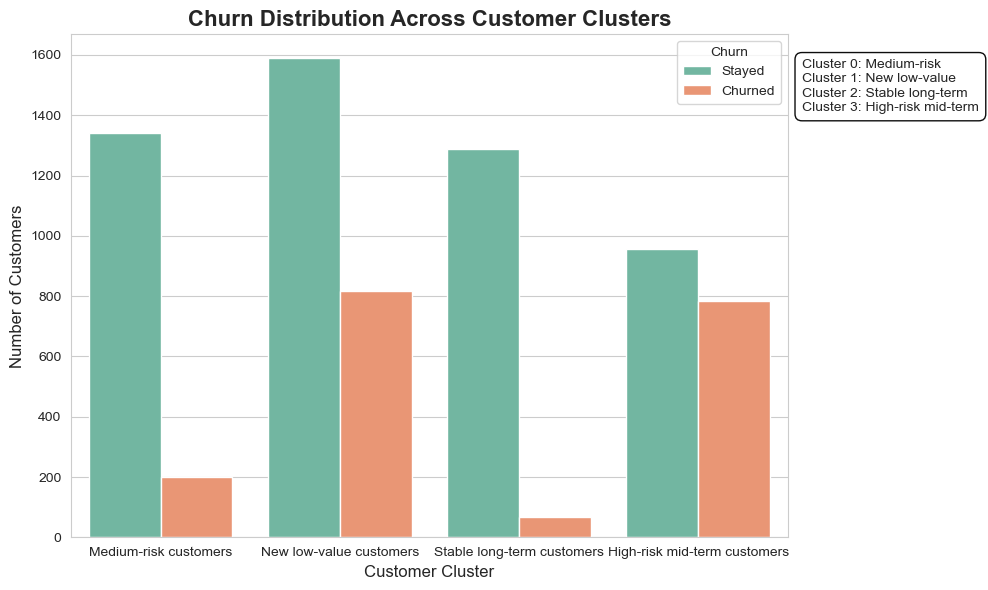

In [72]:


plt.figure(figsize=(10,6))

# Display clusters in the correct order
order = [
    "Medium-risk customers",
    "New low-value customers",
    "Stable long-term customers",
    "High-risk mid-term customers"
]

ax = sns.countplot(
    data=df,
    x="Customer_Type",
    hue="Churn",
    order=order,
    palette="Set2"
)

plt.title("Churn Distribution Across Customer Clusters", fontsize=16, weight="bold")
plt.xlabel("Customer Cluster", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.legend(title="Churn", labels=["Stayed", "Churned"])

# Cluster interpretation
interpretation = (
    "Cluster 0: Medium-risk\n"
    "Cluster 1: New low-value\n"
    "Cluster 2: Stable long-term\n"
    "Cluster 3: High-risk mid-term"
)

plt.text(
    1.02, 0.95,
    interpretation,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="round,pad=0.5",
        alpha=0.95
    )
)

plt.tight_layout()
plt.savefig("Churn Distribution Across Customer Clusters.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [47]:
#calculate Cluster Sizes
# Count customers in each cluster
cluster_counts = df["Cluster"].value_counts().sort_index()

# Calculate percentage of customers in each cluster
cluster_percent = (cluster_counts / len(df) * 100).round(1)

# Create a summary table
cluster_size = pd.DataFrame({
    "Customer Count": cluster_counts,
    "Percentage (%)": cluster_percent
})

cluster_size

,Customer Count,Percentage (%)
Cluster,,
0,1541,21.9
1,2406,34.2
2,1357,19.3
3,1739,24.7


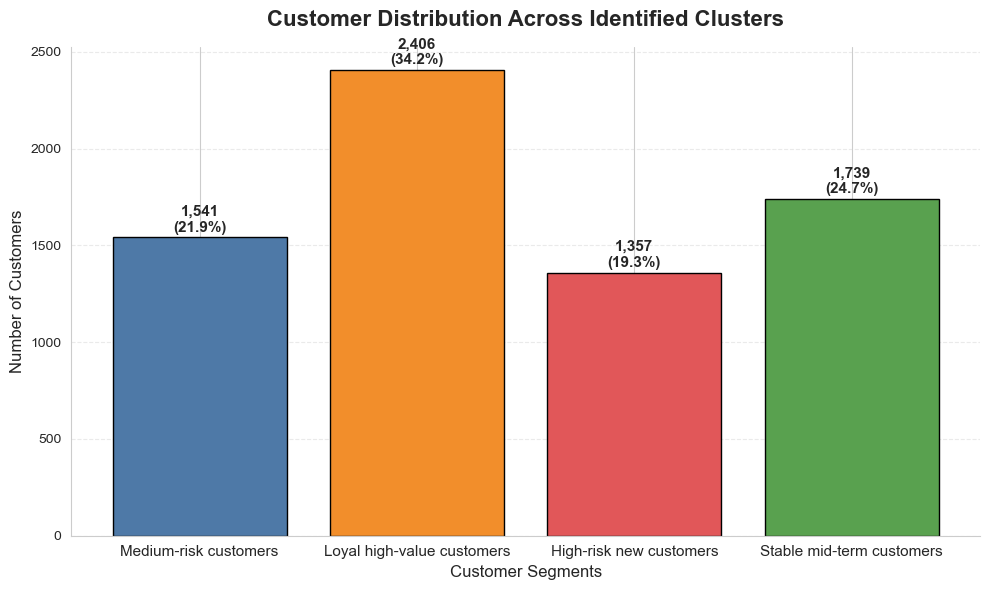

In [56]:

# Cluster counts
cluster_counts = df["Cluster"].value_counts().sort_index()
cluster_percent = (cluster_counts / len(df) * 100).round(1)

# Business names

# Style
sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

colors = ["#4E79A7", "#F28E2B", "#E15759", "#59A14F"]

bars = plt.bar(
    range(4),
    cluster_counts.values,
    color=colors,
    edgecolor="black",
    linewidth=1
)

# Labels above bars
for bar, count, pct in zip(bars, cluster_counts.values, cluster_percent):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 30,
        f"{count:,}\n({pct}%)",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )
cluster_labels = list(cluster_names.values())
plt.xticks(range(4), cluster_labels, fontsize=11)
plt.ylabel("Number of Customers", fontsize=12)
plt.xlabel("Customer Segments", fontsize=12)

plt.title(
    "Customer Distribution Across Identified Clusters",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()

plt.savefig("Cluster_Size_Distribution.png", dpi=300, bbox_inches="tight")

plt.show()